# Lab Day 1 — Mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

**Sinh viên:** Nguyễn Văn Quốc Việt — **MSSV:** 2A202602973

Notebook nằm ở `submission_2A202602973/code/`. Dữ liệu và script ở `../../data`, `../../scripts`;
kết quả ghi vào `../figures/`, `../results/`, `../experiments.xlsx`, `../predictions_eval.csv`, `../eval_result.json`.

**Chạy trên Colab:** *Runtime → Change runtime type → T4 GPU*, rồi *Run all*. Ô đầu tiên tự mount Drive, clone/pull repo
và `cd` vào đúng thư mục `code/`.

Quy tắc: mọi lựa chọn cấu hình chỉ dựa trên **val**. Tập **eval** chỉ dùng ở Part 4 cho baseline và cấu hình cuối cùng.

In [1]:
# ===== (Chỉ trên Colab) mount Drive, clone/pull repo, cd vào submission/code =====
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_URL = "https://github.com/vietvuivui/K4-Track4-Day1-NguyenVanQuocViet-2A202602973-Neuralnetwork.git"
    REPO_DIR = "/content/drive/MyDrive/lab1"          # lưu trên Drive để không mất kết quả khi Colab ngắt
    if not os.path.isdir(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    else:
        !git -C {REPO_DIR} pull
    %cd {REPO_DIR}/submission_2A202602973/code
print("cwd:", os.getcwd())

Mounted at /content/drive
Cloning into '/content/drive/MyDrive/lab1'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 52 (delta 13), reused 48 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 11.77 MiB | 11.57 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/drive/MyDrive/lab1/submission_2A202602973/code
cwd: /content/drive/MyDrive/lab1/submission_2A202602973/code


In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, math, subprocess, importlib
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # = submission_<MSSV>/
sys.path.insert(0, os.getcwd())

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "| bf16 supported:", torch.cuda.is_bf16_supported())
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)
os.makedirs(f"{OUT_DIR}/extra", exist_ok=True)     # dự đoán eval của baseline (không phải file nộp chính)

import data, model, optimizer, train, plots, results_table
for m in (data, model, optimizer, train, plots, results_table):
    importlib.reload(m)                              # sửa .py rồi chạy lại ô này là đủ
from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval, compute_loss
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.11.0+cu130 | device: cuda
GPU: Tesla T4 | bf16 supported: True


## Part 0 — Dữ liệu
Chia sẵn bằng metadata (`scripts/split_data.py`), tách validation 20% **từ train** (phân tầng, seed 42),
chuẩn hoá 10 cột số bằng mean/std của phần train còn lại, đưa toàn bộ lên device một lần.

In [23]:
# ===== Part 0: tạo dữ liệu train / val / eval =====
# 1) Chia train/eval theo metadata (chỉ chạy nếu chưa có file .npz)
if not os.path.exists(f"{REPO_ROOT}/data/processed/train.npz"):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

# 2) Nạp -> tách val 20% (phân tầng, seed 42) -> chuẩn hoá bằng thống kê X_tr -> đưa lên device
#    Seed tách val CỐ ĐỊNH = 42 cho mọi thí nghiệm; seed huấn luyện nằm riêng trong cfg["seed"].
D = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# 3) Kích thước và kiểu dữ liệu
print("\nshape / dtype:")
for k in ["X_tr", "y_tr", "X_val", "y_val", "X_eval", "y_eval"]:
    print(f"  {k:7s} {str(tuple(D[k].shape)):12s} {D[k].dtype}  {D[k].device}")
assert len(D["X_tr"]) == 371_847 and len(D["X_val"]) == 92_962 and len(D["X_eval"]) == 116_203
assert D["X_tr"].dtype == torch.float32 and D["y_tr"].dtype == torch.int64
assert D["y_tr"].min() >= 0 and D["y_tr"].max() <= 6

# 4) Kiểm tra chuẩn hoá: 10 cột số trên X_tr ≈ 0 / 1; 44 cột nhị phân vẫn chỉ có 0/1
num = D["X_tr"][:, :10]
print("\nmean 10 cột số trên X_tr:", num.mean(0).cpu().numpy().round(4))
print("std  10 cột số trên X_tr:", num.std(0).cpu().numpy().round(4))
assert num.mean(0).abs().max() < 1e-3 and (num.std(0) - 1).abs().max() < 1e-3
print("44 cột nhị phân chỉ có giá trị:", torch.unique(D["X_tr"][:, 10:]).tolist())
print("mean/std dùng để chuẩn hoá (fit trên X_tr):\n  mean =", D["mean"].round(2), "\n  std  =", D["std"].round(2))
# val/eval được BIẾN ĐỔI bằng cùng mean/std nên mean của chúng chỉ xấp xỉ 0, không đúng bằng 0:
print("mean 10 cột số trên X_val :", D["X_val"][:, :10].mean(0).cpu().numpy().round(3))

# 5) eval_row_id vẫn gắn đúng thứ tự mẫu eval (dùng để ghi predictions ở Part 4)
ev = np.load(f"{REPO_ROOT}/data/processed/eval.npz")
assert np.array_equal(D["eval_row_id"], ev["row_id"]) and len(D["eval_row_id"]) == len(D["X_eval"])
print("\neval_row_id:", D["eval_row_id"].shape, D["eval_row_id"].dtype, "| 5 giá trị đầu:", D["eval_row_id"][:5],
      "-> cùng thứ tự với eval.npz")

# 6) Lô cuối khi chia batch
from data import iterate_batches
sizes = [len(xb) for xb, _ in iterate_batches(D["X_tr"], D["y_tr"], 512)]
print(f"\nbatch 512: {len(sizes)} lô, lô cuối {sizes[-1]} mẫu, tổng {sum(sizes)} = {len(D['X_tr'])} (giữ lô cuối)")


train (sau tách val): (371847, 54)  val: (92962, 54)  eval: (116203, 54)
lớp đa số (theo train) = 1; accuracy 'luôn đoán lớp đa số' trên val = 0.4876
tỉ lệ lớp (%)  train / val / eval:
  train  36.46  48.76   6.15   0.47   1.63   2.99   3.53
  val    36.46  48.76   6.15   0.47   1.63   2.99   3.53
  eval   36.46  48.76   6.15   0.47   1.63   2.99   3.53

shape / dtype:
  X_tr    (371847, 54) torch.float32  cuda:0
  y_tr    (371847,)    torch.int64  cuda:0
  X_val   (92962, 54)  torch.float32  cuda:0
  y_val   (92962,)     torch.int64  cuda:0
  X_eval  (116203, 54) torch.float32  cuda:0
  y_eval  (116203,)    torch.int64  cuda:0

mean 10 cột số trên X_tr: [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số trên X_tr: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
44 cột nhị phân chỉ có giá trị: [0.0, 1.0]
mean/std dùng để chuẩn hoá (fit trên X_tr):
  mean = [2959.38  155.78   14.11  269.33   46.43 2349.87  212.15  223.31  142.51
 1978.87] 
  std  = [ 280.13  111.95    7.49  212.23   58.24 1557.99

**Nhận xét Part 0:**
- **Kích thước:** train sau khi tách val còn 371 847 mẫu, val 92 962, eval 116 203. X là float32 với 54 cột, y là int64 với giá trị 0..6.
  Tỉ lệ lớp ở train, val và eval gần như bằng nhau nhờ phân tầng.
- **Vai trò:** train dùng để cập nhật tham số. Val dùng để chọn lr, cấu hình và epoch. Eval chỉ dùng một lần ở Part 4.
  Seed tách val cố định là 42 cho mọi thí nghiệm. Khi đổi seed huấn luyện, phép tách vẫn giữ nguyên, nên các thí nghiệm so trên cùng dữ liệu.
- **Chuẩn hoá:** chỉ chuẩn hoá 10 cột số. mean/std tính **chỉ trên X_tr**, sau đó dùng chính mean/std này để biến đổi cả val và eval.
  44 cột nhị phân giữ nguyên. Trên X_tr, mean ≈ 0 và std ≈ 1. Trên X_val, mean chỉ xấp xỉ 0, vì val được biến đổi bằng thống kê của train.
- **Vì sao val/eval không tham gia tính mean/std:** nếu tính thống kê có cả val/eval, thông tin về dữ liệu dùng để đánh giá
  sẽ rò rỉ vào bước tiền xử lý. Khi đó điểm đánh giá không còn phản ánh đúng dữ liệu mới, chưa thấy. Được phép *áp dụng*
  phép biến đổi lên eval, nhưng không được *dùng eval để tính* thống kê.
- **Mốc thấp nhất:** luôn đoán lớp đa số (lớp 1) cho accuracy 0,4876 trên val. Model phải vượt mốc này.
- **eval_row_id** giữ nguyên thứ tự của eval.npz. Eval không bị xáo hay tách, nên ở Part 4 dự đoán sẽ ghép đúng với row_id.
- **Lô cuối:** 371 847 không chia hết cho 512, nên có 727 lô và lô cuối chỉ 135 mẫu. Mình **giữ lại** lô này (không drop_last)
  để mỗi epoch dùng đủ mọi mẫu. Lô nhỏ cho gradient nhiễu hơn, nhưng chỉ chiếm 1/727 số bước nên ảnh hưởng không đáng kể.


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
`M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model. Khởi tạo He (`kaiming_normal_`, bias = 0).

In [24]:
# 1a-1b: kiến trúc, số tham số, khởi tạo He, shape qua từng lớp
set_seed(0)
m = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
print(m)
n_params = count_params(m)
print("số tham số:", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879        # assert ngay sau khi tạo model

import torch.nn as nn
assert not any(isinstance(l, (nn.Softmax, nn.BatchNorm1d, nn.LayerNorm)) for l in m.modules())
print("\nKiểm tra từng lớp Linear (He: std(W) ≈ sqrt(2/n_in), bias = 0):")
for l in m.net:
    if isinstance(l, nn.Linear):
        assert l.bias is not None
        print(f"  Linear({l.in_features:3d} -> {l.out_features:3d})  tham số = {l.weight.numel() + l.bias.numel():6d}  "
              f"std(W) = {l.weight.std().item():.4f}  vs He {math.sqrt(2 / l.in_features):.4f}  bias=0: {bool((l.bias == 0).all())}")
print(f"  (đối chứng: mặc định nn.Linear cho std(W1) = {MLP(init='default').net[0].weight.std().item():.4f} -> KHÔNG phải He)")

print("\nShape qua từng lớp với lô (8, 54):")
xb = torch.randn(8, 54, device=device)
h = xb
for layer in m.net:
    h = layer(h)
    print(f"  sau {layer.__class__.__name__:7s}: {tuple(h.shape)}")
assert m(xb).shape == (8, 7)

for hid in [(512, 256), (256, 128, 64)]:
    assert count_params(MLP(hidden=hid)) == EXPECTED_PARAMS[hid]
print("\nM-wide = 161 287, M-deep = 55 687 tham số: khớp quy định")
print("Dropout q=0.3 (chỉ sau ReLU lớp ẩn):", [l.__class__.__name__ for l in MLP(dropout=0.3).net])


MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879

Kiểm tra từng lớp Linear (He: std(W) ≈ sqrt(2/n_in), bias = 0):
  Linear( 54 -> 256)  tham số =  14080  std(W) = 0.1936  vs He 0.1925  bias=0: True
  Linear(256 -> 128)  tham số =  32896  std(W) = 0.0885  vs He 0.0884  bias=0: True
  Linear(128 ->   7)  tham số =    903  std(W) = 0.1246  vs He 0.1250  bias=0: True
  (đối chứng: mặc định nn.Linear cho std(W1) = 0.0788 -> KHÔNG phải He)

Shape qua từng lớp với lô (8, 54):
  sau Linear : (8, 256)
  sau ReLU   : (8, 256)
  sau Linear : (8, 128)
  sau ReLU   : (8, 128)
  sau Linear : (8, 7)

M-wide = 161 287, M-deep = 55 687 tham số: khớp quy định
Dropout q=0.3 (chỉ sau ReLU lớp ẩn): ['Linear', 'ReLU', 'Dropout', 'Linear', 'ReLU', 'Dropout', 'Linear']


In [5]:
# 1c-1: loss bước 0 trên val (eval mode) ≈ ln 7
step0 = evaluate(m, D["X_val"], D["y_val"], "ce")
print(f"loss bước 0 trên val = {step0['loss']:.4f}   (ln 7 = {math.log(7):.4f}, lệch {step0['loss'] - math.log(7):+.4f})")
print(f"accuracy bước 0 = {step0['acc']:.4f}")

loss bước 0 trên val = 2.2073   (ln 7 = 1.9459, lệch +0.2614)
accuracy bước 0 = 0.0801


loss đầu = 1.9668, loss cuối = 0.000004, accuracy trên 20 mẫu = 1.00


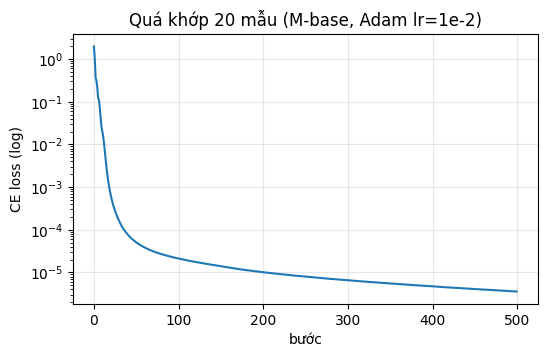

In [6]:
# 1c-2: quá khớp 20 mẫu (không dropout, Adam lr 1e-2, 500 bước)
set_seed(0)
m20 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt20 = torch.optim.Adam(m20.parameters(), lr=1e-2)
x20, y20 = D["X_tr"][:20], D["y_tr"][:20]
losses20 = []
for step in range(500):
    m20.train()
    loss = compute_loss(m20(x20), y20, "ce")
    opt20.zero_grad(set_to_none=True); loss.backward(); opt20.step()
    losses20.append(loss.item())
acc20 = (predict(m20, x20) == y20).float().mean().item()
print(f"loss đầu = {losses20[0]:.4f}, loss cuối = {losses20[-1]:.6f}, accuracy trên 20 mẫu = {acc20:.2f}")
plt.figure(figsize=(6, 3.5)); plt.semilogy(losses20)
plt.title("Quá khớp 20 mẫu (M-base, Adam lr=1e-2)"); plt.xlabel("bước"); plt.ylabel("CE loss (log)"); plt.grid(alpha=.3)
plt.show()

In [7]:
# 1d: gradient có chảy tới mọi tham số?
set_seed(0)
mg = MLP(hidden=(256, 128), init="he").to(device)
loss = compute_loss(mg(D["X_tr"][:512]), D["y_tr"][:512], "ce")
loss.backward()
for name, p in mg.named_parameters():
    g = p.grad
    print(f"  {name:14s} shape={tuple(p.shape)!s:12s} ‖grad‖ = {g.norm().item():.4e}")
    assert g is not None and g.norm().item() > 0, name
print("Mọi tham số đều có gradient khác 0.")

  net.0.weight   shape=(256, 54)    ‖grad‖ = 4.5429e-01
  net.0.bias     shape=(256,)       ‖grad‖ = 2.6839e-01
  net.2.weight   shape=(128, 256)   ‖grad‖ = 1.7565e+00
  net.2.bias     shape=(128,)       ‖grad‖ = 3.8244e-01
  net.4.weight   shape=(7, 128)     ‖grad‖ = 1.9387e+00
  net.4.bias     shape=(7,)         ‖grad‖ = 5.4980e-01
Mọi tham số đều có gradient khác 0.


**Nhận xét Part 1:**
- **Kiến trúc:** M-base `54 → 256 → 128 → 7` có đúng 47 879 tham số. Mọi Linear đều có bias, lớp ẩn dùng ReLU, không có softmax/BatchNorm.
  Đầu ra là logit thô (8, 7); `F.cross_entropy` tự áp softmax bên trong.
- **Khởi tạo He:** std(W) đo được khớp √(2/n_in) ở cả 3 lớp, bias = 0 ⇒ đúng là He, không phải mặc định của nn.Linear
  (mặc định có std nhỏ hơn khoảng 2,5 lần).
- **Loss bước 0** trên val (eval mode, trước khi cập nhật, seed 0) = **2,2073**, so với ln 7 = 1,9459 ⇒ lệch **+0,26**.
  Giải thích: ln 7 chỉ đạt được khi 7 logit bằng nhau (softmax đều). He giữ phương sai kích hoạt qua các lớp, và lớp ra cũng khởi tạo He
  (Var = 2/128), nên logit có std ≈ 0,58 (bảng activation_stats ở Chủ đề 7) chứ không ≈ 0 ⇒ softmax lệch ngẫu nhiên ⇒ loss cao hơn ln 7 một chút.
  Mức lệch nhỏ (accuracy bước 0 = 0,08 ≈ đoán ngẫu nhiên), không phải dấu hiệu lỗi chuẩn hoá hay nhãn (lỗi thật cho loss ≫ ln 7).
  Đối chứng: init `zeros`/`normal` (logit ≈ 0) cho đúng 1,946. Trong bảng thí nghiệm, `base-s1` (seed 1) có step0 = 2,269 — cùng hiện tượng, khác seed.
- **Quá khớp 20 mẫu** (Adam lr 1e-2, không dropout): loss từ 1,9668 về 0,000004 sau 500 bước, accuracy 100% ⇒ model, loss, `zero_grad`, `backward`
  và optimizer phối hợp đúng. Đây chỉ là bằng chứng *khớp được* một lô nhỏ, chưa phải tổng quát hoá.
- **Gradient:** sau một lần `backward()`, cả 6 tham số W1, b1, W2, b2, W3, b3 đều có gradient khác None và khác 0 ⇒ gradient chảy tới mọi lớp.

## Part 2 — Pipeline và baseline
Baseline: M-base, SGD + momentum 0,9, CE, He, batch 512, 20 epoch, không dropout/clip, FP32.

Các hàm tiện ích bên dưới: `run()` chạy một cấu hình, lưu `results/<exp_id>.json` và `figures/<exp_id>.png`.
Nếu Colab ngắt giữa chừng, chạy lại notebook sẽ **nạp lại** kết quả đã có thay vì huấn luyện lại (đặt `FORCE = True` để chạy lại tất cả).

In [8]:
FORCE = False
RESULTS = {}

def run(cfg, force=False, verbose=False):
    cfg = {**DEFAULT_CFG, **cfg}
    path = f"{OUT_DIR}/results/{cfg['exp_id']}.json"
    if os.path.exists(path) and not (force or FORCE):
        with open(path, encoding="utf-8") as f:
            r = json.load(f)
        same = all(r["cfg"].get(k) == (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items())
        if same:
            RESULTS[cfg["exp_id"]] = r
            s = r["summary"]
            print(f"[nạp lại] {cfg['exp_id']:24s} val_F1={s['val_macro_f1']:.4f} val_acc={s['val_acc']:.4f}")
            return r
    r = run_experiment(cfg, D, verbose=verbose)
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{cfg['exp_id']}.png")
    RESULTS[cfg["exp_id"]] = r
    s = r["summary"]
    print(f"[chạy]    {cfg['exp_id']:24s} val_F1={s['val_macro_f1']:.4f} val_acc={s['val_acc']:.4f} "
          f"best_ep={s['best_epoch']:2d} step0={s['step0_loss']:.3f} {s['time_per_epoch_s'] or 0:.1f}s/ep"
          + ("  DIVERGED" if s["diverged"] else ""))
    return r

def ensure_state(exp_id):
    # Cần best_state (trọng số) để dự đoán eval. Nếu kết quả được nạp từ JSON (không có trọng số) thì huấn luyện lại
    # ĐÚNG cấu hình + seed đó, KHÔNG ghi đè JSON/ảnh, và kiểm tra val macro-F1 khớp với bảng.
    r = RESULTS[exp_id]
    if "best_state" in r:
        return r
    cfg = dict(r["cfg"]); cfg["hidden"] = tuple(cfg["hidden"])
    r2 = run_experiment(cfg, D, verbose=False)
    f_old, f_new = r["summary"]["val_macro_f1"], r2["summary"]["val_macro_f1"]
    print(f"[huấn luyện lại để lấy trọng số] {exp_id}: val_F1 trong bảng {f_old:.4f} | chạy lại {f_new:.4f} | lệch {f_new - f_old:+.5f}")
    if abs(f_new - f_old) > 1e-3:
        # GPU khác loại có thể cho số hơi khác: dùng lần chạy mới và cập nhật JSON/ảnh để bảng khớp với eval
        print("  lệch > 1e-3 -> cập nhật results/ và figures/ của", exp_id)
        save_result(r2, f"{OUT_DIR}/results"); plot_run(r2, f"{OUT_DIR}/figures/{exp_id}.png")
        RESULTS[exp_id] = r2
        return r2
    RESULTS[exp_id] = {**r, "best_state": r2["best_state"]}
    return RESULTS[exp_id]

def table(ids, base_mean=None, two_sigma=None):
    rows = []
    for i in ids:
        r = RESULTS[i]; s = r["summary"]; c = r["cfg"]
        row = dict(exp_id=i, opt=c["optimizer"], lr=c["lr"], batch=c["batch"], hidden="-".join(map(str, c["hidden"])),
                   drop=c["dropout"], clip=c["clip_norm"], prec=c["precision"], init=c["init"],
                   step0=s["step0_loss"], best_ep=s["best_epoch"], best_val_loss=s["best_val_loss"],
                   gap=(s["final_val_loss"] - s["final_train_loss"]) if s["final_val_loss"] is not None else None,
                   val_acc=s["val_acc"], val_f1=s["val_macro_f1"], s_per_ep=s["time_per_epoch_s"],
                   mem_MB=s["peak_mem_MB"], diverged=s["diverged"])
        if base_mean is not None:
            row["ΔF1_vs_base"] = s["val_macro_f1"] - base_mean
            row["vượt 2σ?"] = "Có" if two_sigma and abs(row["ΔF1_vs_base"]) > two_sigma else "Không"
        rows.append(row)
    return pd.DataFrame(rows).set_index("exp_id").round(4)

### 2a. Chọn lr cho baseline bằng val
SGD + momentum, thử lr ∈ {0,01; 0,03; 0,1} (seed 1). Chọn lr có **val macro-F1** cao nhất. Lần chạy của lr được chọn chính là `base-s1`;
các lr còn lại giữ lại thành dòng nhóm `hparam` (thí nghiệm lr).

In [9]:
LR_GRID = [0.01, 0.03, 0.1]
sweep = {}
for lr in LR_GRID:
    cfg_lr = {"exp_id": f"hp-sgdm-lr{lr}", "group": "hparam",
              "description": f"Baseline nhưng lr={lr} (chọn lr cho baseline)", "lr": lr}
    # Lần thử ứng với lr được chọn đã được gộp vào base-s1 (cùng cấu hình, cùng seed): khi chạy lại, nạp base-s1 thay vì huấn luyện lại
    if not os.path.exists(f"{OUT_DIR}/results/hp-sgdm-lr{lr}.json") and os.path.exists(f"{OUT_DIR}/results/base-s1.json") and not FORCE:
        with open(f"{OUT_DIR}/results/base-s1.json", encoding="utf-8") as f:
            r_b = json.load(f)
        if r_b["cfg"]["lr"] == lr:
            r_b["cfg"] = {**r_b["cfg"], "exp_id": cfg_lr["exp_id"]}
            RESULTS[cfg_lr["exp_id"]] = sweep[lr] = r_b
            print(f"[nạp lại] hp-sgdm-lr{lr:<5}            (= base-s1) val_F1={r_b['summary']['val_macro_f1']:.4f}")
            continue
    sweep[lr] = run(cfg_lr)
display(table([f"hp-sgdm-lr{lr}" for lr in LR_GRID]))

BASE_LR = max(LR_GRID, key=lambda lr: sweep[lr]["summary"]["val_macro_f1"])
print("lr baseline chọn theo val macro-F1:", BASE_LR)
BASE_CFG = {**DEFAULT_CFG, "lr": BASE_LR}

[chạy]    hp-sgdm-lr0.01           val_F1=0.7613 val_acc=0.8747 best_ep=20 step0=2.269 1.3s/ep
[chạy]    hp-sgdm-lr0.03           val_F1=0.8170 val_acc=0.8921 best_ep=20 step0=2.269 1.3s/ep
[chạy]    hp-sgdm-lr0.1            val_F1=0.8390 val_acc=0.9054 best_ep=18 step0=2.269 1.2s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,,,,,,,
hp-sgdm-lr0.01,sgd_momentum,0.01,512,256-128,0.0,None,fp32,he,2.2691,20,0.3110,0.0086,0.8747,0.7613,1.2934,162.4209,False
hp-sgdm-lr0.03,sgd_momentum,0.03,512,256-128,0.0,None,fp32,he,2.2691,20,0.2660,0.0160,0.8921,0.8170,1.2543,162.6040,False
hp-sgdm-lr0.1,sgd_momentum,0.10,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2413,162.7871,False


lr baseline chọn theo val macro-F1: 0.1


### 2b. Baseline với 3 seed → độ nhiễu

In [10]:
SEEDS = [1, 2, 3]
for s in SEEDS:
    run({**BASE_CFG, "seed": s, "exp_id": f"base-s{s}", "group": "baseline",
         "description": f"Baseline M-base, seed {s}"}, verbose=(s == 1))

# lần chạy hp-sgdm-lr<BASE_LR> trùng cấu hình với base-s1 -> bỏ khỏi bảng để không lặp dòng
dup = f"{OUT_DIR}/results/hp-sgdm-lr{BASE_LR}.json"
if os.path.exists(dup):
    os.remove(dup)
    if os.path.exists(f"{OUT_DIR}/figures/hp-sgdm-lr{BASE_LR}.png"):
        os.remove(f"{OUT_DIR}/figures/hp-sgdm-lr{BASE_LR}.png")
RESULTS.pop(f"hp-sgdm-lr{BASE_LR}", None)

base_ids = [f"base-s{s}" for s in SEEDS]
f1s = np.array([RESULTS[i]["summary"]["val_macro_f1"] for i in base_ids])
accs = np.array([RESULTS[i]["summary"]["val_acc"] for i in base_ids])
BASE_MEAN, BASE_STD = f1s.mean(), f1s.std(ddof=1)
TWO_SIGMA = 2 * BASE_STD
print(f"val macro-F1 baseline: {BASE_MEAN:.4f} ± {BASE_STD:.4f}  (2σ = {TWO_SIGMA:.4f})")
print(f"val acc baseline     : {accs.mean():.4f} ± {accs.std(ddof=1):.4f}")
display(table(base_ids, BASE_MEAN, TWO_SIGMA))
plot_compare([RESULTS[i] for i in base_ids], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_baseline_seeds.png", "Baseline — 3 seed")

[base-s1] ep  1 | train 0.4627 | val 0.4675 | acc 0.7997 | F1 0.6243 | gn 0.530 | 1.4s
[base-s1] ep  2 | train 0.3950 | val 0.3996 | acc 0.8300 | F1 0.7038 | gn 0.567 | 1.2s
[base-s1] ep  3 | train 0.3792 | val 0.3862 | acc 0.8357 | F1 0.7256 | gn 0.564 | 1.2s
[base-s1] ep  4 | train 0.3721 | val 0.3800 | acc 0.8455 | F1 0.7412 | gn 0.575 | 1.1s
[base-s1] ep  5 | train 0.3109 | val 0.3204 | acc 0.8671 | F1 0.7825 | gn 0.572 | 1.1s
[base-s1] ep  6 | train 0.3042 | val 0.3151 | acc 0.8707 | F1 0.7949 | gn 0.587 | 1.1s
[base-s1] ep  7 | train 0.2937 | val 0.3047 | acc 0.8745 | F1 0.7924 | gn 0.580 | 1.2s
[base-s1] ep  8 | train 0.2806 | val 0.2936 | acc 0.8780 | F1 0.7961 | gn 0.571 | 1.2s
[base-s1] ep  9 | train 0.2925 | val 0.3068 | acc 0.8772 | F1 0.8026 | gn 0.575 | 1.3s
[base-s1] ep 10 | train 0.2717 | val 0.2900 | acc 0.8833 | F1 0.8046 | gn 0.579 | 1.3s
[base-s1] ep 11 | train 0.2499 | val 0.2629 | acc 0.8922 | F1 0.8307 | gn 0.563 | 1.3s
[base-s1] ep 12 | train 0.2446 | val 0.2599

,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
base-s2,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,1.9782,19,0.2279,0.0262,0.9100,0.8601,1.2162,163.1533,False,0.0065,Không
base-s3,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,1.9005,19,0.2277,0.0228,0.9091,0.8614,1.2281,163.3364,False,0.0079,Không


lr đã thử (val macro-F1 / val acc ở best epoch):
  lr=0.01  -> F1 0.7613 | acc 0.8747 | best_epoch 20
  lr=0.03  -> F1 0.8170 | acc 0.8921 | best_epoch 20
  lr=0.1   -> F1 0.8390 | acc 0.9054 | best_epoch 18   <- chọn

base-s1: step0 2.269 | best_epoch 18 | val_loss ep1 0.4675 -> ep10 0.2900 -> ep20 0.2426 | giảm 5 epoch cuối +0.0183
   train_loss cuối 0.2223, val_loss cuối 0.2426 -> gap val-train +0.0202
   val_acc 0.9054 (mốc đoán đa số 0.4876) | val_F1 0.8390 | grad_norm TB 0.567 | 1.2s/epoch | peak mem 162.97021484375 MB

base-s2: step0 1.978 | best_epoch 19 | val_loss ep1 0.4853 -> ep10 0.2861 -> ep20 0.2325 | giảm 5 epoch cuối +0.0075
   train_loss cuối 0.2063, val_loss cuối 0.2325 -> gap val-train +0.0262
   val_acc 0.9100 (mốc đoán đa số 0.4876) | val_F1 0.8601 | grad_norm TB 0.555 | 1.2s/epoch | peak mem 163.1533203125 MB

base-s3: step0 1.901 | best_epoch 19 | val_loss ep1 0.4845 -> ep10 0.2619 -> ep20 0.2375 | giảm 5 epoch cuối +0.0183
   train_loss cuối 0.2147, val_loss cuố

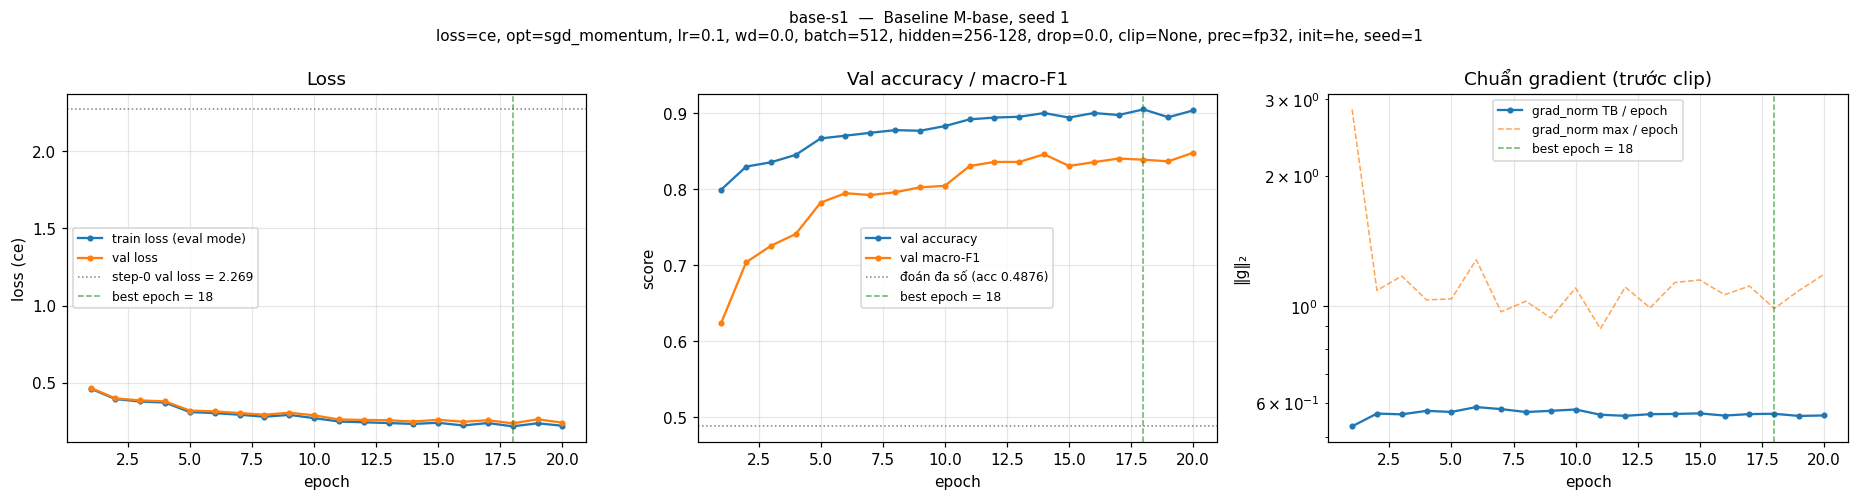

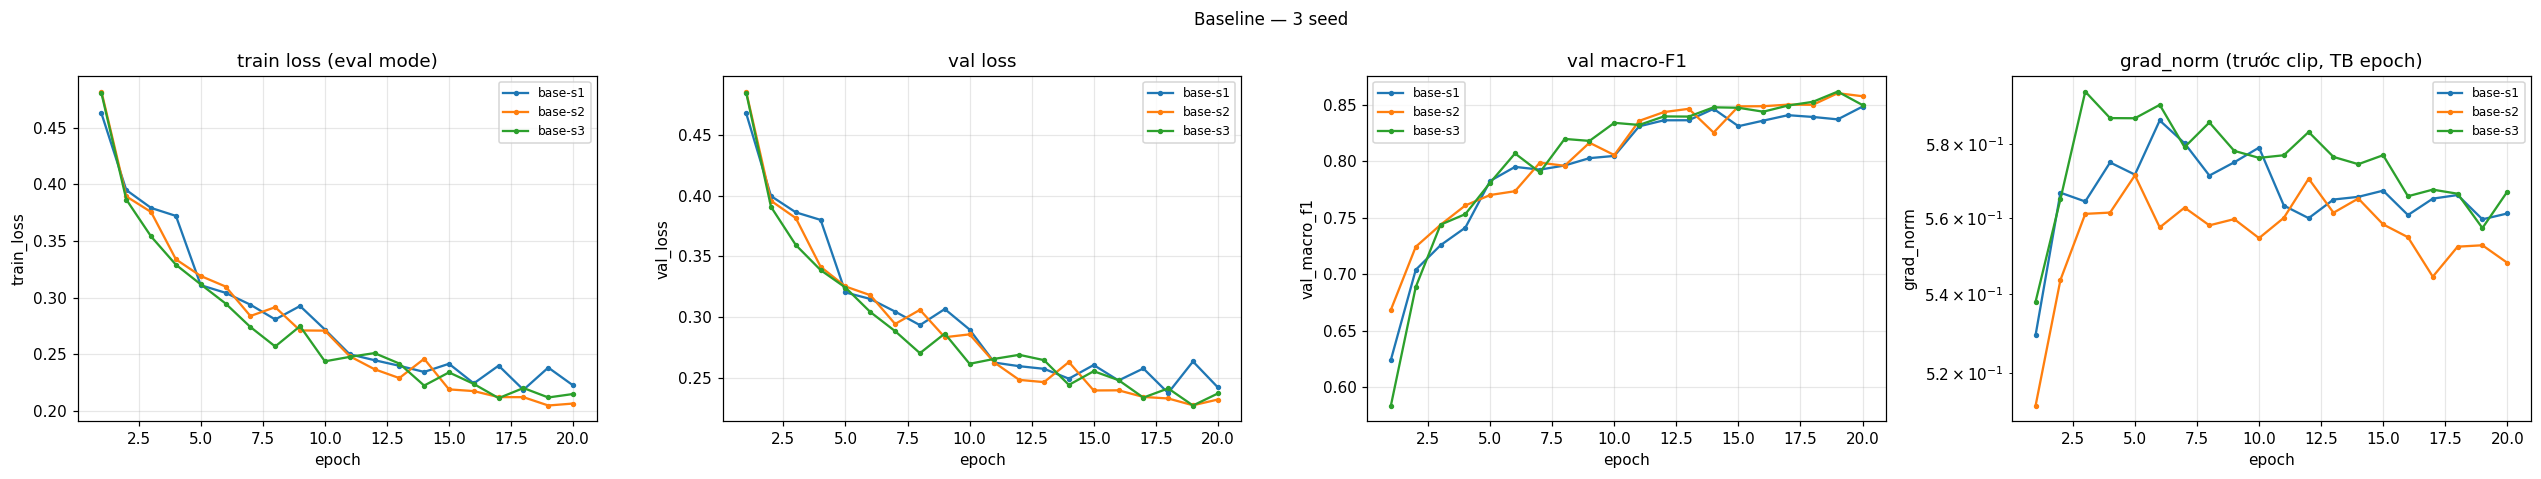

In [25]:
# Số liệu để nhận xét baseline
from IPython.display import Image
print("lr đã thử (val macro-F1 / val acc ở best epoch):")
for lr in LR_GRID:
    i = "base-s1" if lr == BASE_LR else f"hp-sgdm-lr{lr}"
    s = RESULTS[i]["summary"]
    print(f"  lr={lr:<5} -> F1 {s['val_macro_f1']:.4f} | acc {s['val_acc']:.4f} | best_epoch {s['best_epoch']}"
          + ("   <- chọn" if lr == BASE_LR else ""))

for i in base_ids:
    h, s = RESULTS[i]["history"], RESULTS[i]["summary"]
    vl = h["val_loss"]
    print(f"\n{i}: step0 {s['step0_loss']:.3f} | best_epoch {s['best_epoch']} | val_loss ep1 {vl[0]:.4f} -> ep10 {vl[9]:.4f} -> ep20 {vl[-1]:.4f}"
          f" | giảm 5 epoch cuối {vl[-6] - vl[-1]:+.4f}")
    print(f"   train_loss cuối {s['final_train_loss']:.4f}, val_loss cuối {s['final_val_loss']:.4f} -> gap val-train {s['final_val_loss'] - s['final_train_loss']:+.4f}")
    print(f"   val_acc {s['val_acc']:.4f} (mốc đoán đa số 0.4876) | val_F1 {s['val_macro_f1']:.4f} | grad_norm TB {np.mean(h['grad_norm']):.3f}"
          f" | {s['time_per_epoch_s']:.1f}s/epoch | peak mem {s['peak_mem_MB']} MB")

print(f"\nĐộ nhiễu 3 seed: val F1 = {BASE_MEAN:.4f} ± {BASE_STD:.4f} (2σ = {TWO_SIGMA:.4f}); "
      f"val acc = {accs.mean():.4f} ± {accs.std(ddof=1):.4f}")
display(Image(f"{OUT_DIR}/figures/base-s1.png"))
display(Image(f"{OUT_DIR}/figures/compare_baseline_seeds.png"))


**Nhận xét baseline:**
- **Chọn lr:** SGD+momentum 0,9, seed 1, lr ∈ {0,01; 0,03; 0,1} cho val macro-F1 lần lượt 0,7613 / 0,8170 / 0,8390 ⇒ chọn **lr = 0,1** theo val
  (không nhìn eval). **Hạn chế:** 0,1 nằm ở biên lưới và F1 còn tăng theo lr, nên lr tối ưu có thể lớn hơn 0,1 (`clip-none-highlr` với lr = 1
  cho F1 0,7732 ⇒ tối ưu nằm đâu đó giữa 0,1 và 1, chưa đo).
- **Cách đo:** train loss đo ở eval mode trên một tập con **cố định 50 000 mẫu** đầu của X_tr (split đã được xáo nên tập con đại diện).
  grad_norm là chuẩn L2 toàn cục trước clip, trung bình theo epoch. Metric báo cáo lấy tại epoch có val loss thấp nhất.
- **Hình dạng đường cong (base-s1):** val loss giảm nhanh từ 0,4675 (epoch 1) xuống 0,2900 (epoch 10) rồi chậm dần tới 0,2426 (epoch 20);
  5 epoch cuối vẫn giảm 0,018 ⇒ **chưa hội tụ hẳn**, có dao động nhỏ (best epoch = 18, không phải 20). Train và val loss gần trùng nhau
  (gap cuối = 0,020) ⇒ **chưa quá khớp**: 48k tham số còn nhỏ so với 372k mẫu. Huấn luyện lâu hơn / lr lớn hơn có thể còn cải thiện.
  grad_norm trung bình ổn định quanh 0,53–0,59 qua các epoch (max theo bước 2,84), không có gai lớn.
- **So với mốc:** val acc 0,9054 ≫ 0,4876 (đoán đa số), val macro-F1 0,8390 ≫ 0,094 ⇒ model học được, không chỉ đoán lớp đa số.
  Khoảng cách acc–F1 (0,91 vs 0,84) cho thấy các lớp hiếm (3, 4, 5) còn bị dự đoán kém hơn hẳn.
- **Độ nhiễu (seed 1, 2, 3; cùng phép tách val):** val macro-F1 = **0,8535 ± 0,0126**, val acc = 0,9082 ± 0,0024.
  **Ngưỡng 2σ = 0,0252** cho macro-F1: chênh lệch nhỏ hơn mức này được coi là *chưa kết luận được*. Nhiễu của macro-F1 lớn hơn accuracy
  ~5 lần vì F1 các lớp hiếm (vài trăm mẫu val) dao động mạnh theo seed. Seed 1 thấp hơn hẳn 2 seed còn lại (0,839 vs 0,860/0,861)
  ⇒ so sánh 1-seed với `base-s1` dễ phóng đại cải thiện; vì vậy mọi so sánh dưới đây dùng **trung bình 3 seed**. 3 seed chỉ cho ước lượng σ thô.

## Part 3 — Thí nghiệm
Mỗi thí nghiệm đổi **một** yếu tố so với baseline (seed 1, 20 epoch, cùng split). So sánh với **trung bình baseline** và ngưỡng **2σ**.

### Chủ đề 1 — Hàm mất mát: CE vs MSE (`loss-mse`)
**Dự đoán trước:** MSE trên logit với one-hot cho gradient tuyến tính theo sai số và không "phạt mạnh" dự đoán sai nặng như CE (gradient CE
theo logit = softmax − one-hot, không bão hoà). MSE cũng đối xử các lớp hiếm kém hơn ⇒ dự đoán val macro-F1 của MSE **thấp hơn** CE và hội tụ chậm hơn.
MSE: `F.mse_loss(logits, one_hot)` lấy trung bình trên B×7 phần tử, không hệ số 1/2. So sánh bằng accuracy/macro-F1, không so loss.

In [11]:
run({**BASE_CFG, "exp_id": "loss-mse", "group": "loss", "description": "MSE trên logit vs one-hot thay cho CE", "loss": "mse"})
display(table(["base-s1", "loss-mse"], BASE_MEAN, TWO_SIGMA))
plot_compare([RESULTS["base-s1"], RESULTS["loss-mse"]], ["val_acc", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_loss.png", "CE vs MSE (so bằng metric, không so loss)")

[chạy]    loss-mse                 val_F1=0.7277 val_acc=0.8705 best_ep=20 step0=0.636 1.3s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
loss-mse,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,0.6359,20,0.0293,0.0008,0.8705,0.7277,1.2865,163.5229,False,-0.1258,Có


**Đối chiếu sau khi chạy (loss):** dự đoán **khớp**. `loss-mse` đạt val macro-F1 **0,7277** (acc 0,8705) so với baseline 0,8535 ± 0,0126
⇒ Δ = −0,126, vượt xa 2σ = 0,025 (1 seed cho MSE nhưng chênh lệch gấp 5 lần ngưỡng). Hội tụ cũng chậm hơn: F1 ở epoch 5 là 0,616 so với 0,782 của CE.
Cơ chế: gradient của CE theo logit là (softmax − one-hot), lớn khi dự đoán sai nặng và không bão hoà; MSE trên logit có gradient 2(z − y)/7
nhỏ hơn và không "đẩy" xác suất lớp đúng mạnh như CE; ngoài ra MSE tối ưu khoảng cách tới vector one-hot chứ không trực tiếp tối ưu
xác suất lớp đúng, nên các lớp hiếm bị ưu tiên thấp ⇒ macro-F1 giảm mạnh hơn accuracy. (Không so độ lớn loss: thang đo khác nhau.)

### Chủ đề 2 — Bộ tối ưu hoá (mỗi bộ ≥ 2 lr, so ở lr tốt nhất của mỗi bộ)
- SGD (không momentum): lr ∈ {0,1; 0,3} (+ lr baseline đã có trong sweep nếu cần)
- SGD + momentum: dùng kết quả sweep ở Part 2 (0,01 / 0,03 / 0,1)
- Adam: lr ∈ {3e-4; 1e-3; 3e-3}
- AdamW (`weight_decay = 0,01`): lr ∈ {1e-3; 3e-3}

**Dự đoán trước:** SGD thuần cần lr lớn hơn SGD+momentum để đi cùng quãng đường (momentum ≈ nhân bước hiệu dụng 1/(1−μ) = 10 lần).
Adam chia bước theo độ lớn gradient từng tham số nên hội tụ nhanh ở vài epoch đầu; ở lr tốt nhất của mỗi bộ, Adam/AdamW sẽ cao hơn SGD+momentum
một chút. AdamW với wd = 0,01 gần như bằng Adam (mạng nhỏ, chưa quá khớp nhiều).

In [12]:
OPT_GRID = {"sgd": [0.1, 0.3], "adam": [3e-4, 1e-3, 3e-3], "adamw": [1e-3, 3e-3]}
for opt, lrs in OPT_GRID.items():
    for lr in lrs:
        run({**BASE_CFG, "exp_id": f"opt-{opt}-lr{lr:g}", "group": "optimizer",
             "description": f"{opt} lr={lr:g}" + (" wd=0.01" if opt == "adamw" else ""),
             "optimizer": opt, "lr": lr, "weight_decay": 0.01 if opt == "adamw" else 0.0})

opt_runs = {"sgd": [f"opt-sgd-lr{lr:g}" for lr in OPT_GRID["sgd"]],
            "sgd_momentum": [f"hp-sgdm-lr{lr}" for lr in LR_GRID if lr != BASE_LR] + ["base-s1"],
            "adam": [f"opt-adam-lr{lr:g}" for lr in OPT_GRID["adam"]],
            "adamw": [f"opt-adamw-lr{lr:g}" for lr in OPT_GRID["adamw"]]}
display(table([i for ids in opt_runs.values() for i in ids], BASE_MEAN, TWO_SIGMA))

BEST_OPT = {k: max(ids, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"]) for k, ids in opt_runs.items()}
print("lr tốt nhất của mỗi bộ (theo val macro-F1):", BEST_OPT)
plot_compare([RESULTS[i] for i in BEST_OPT.values()], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_optimizer.png", "Bộ tối ưu — mỗi bộ ở lr tốt nhất của nó")

[chạy]    opt-sgd-lr0.1            val_F1=0.7551 val_acc=0.8580 best_ep=18 step0=2.269 1.2s/ep
[chạy]    opt-sgd-lr0.3            val_F1=0.8163 val_acc=0.8871 best_ep=18 step0=2.269 1.2s/ep
[chạy]    opt-adam-lr0.0003        val_F1=0.7877 val_acc=0.8727 best_ep=20 step0=2.269 1.4s/ep
[chạy]    opt-adam-lr0.001         val_F1=0.8456 val_acc=0.8993 best_ep=19 step0=2.269 1.5s/ep
[chạy]    opt-adam-lr0.003         val_F1=0.8677 val_acc=0.9153 best_ep=19 step0=2.269 1.4s/ep
[chạy]    opt-adamw-lr0.001        val_F1=0.8482 val_acc=0.9004 best_ep=20 step0=2.269 1.5s/ep
[chạy]    opt-adamw-lr0.003        val_F1=0.8646 val_acc=0.9130 best_ep=18 step0=2.269 1.4s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
opt-sgd-lr0.1,sgd,0.1000,512,256-128,0.0,None,fp32,he,2.2691,18,0.3475,0.0059,0.8580,0.7551,1.1931,163.5195,False,-0.0985,Có
opt-sgd-lr0.3,sgd,0.3000,512,256-128,0.0,None,fp32,he,2.2691,18,0.2803,0.0118,0.8871,0.8163,1.2149,163.7026,False,-0.0372,Có
hp-sgdm-lr0.01,sgd_momentum,0.0100,512,256-128,0.0,None,fp32,he,2.2691,20,0.3110,0.0086,0.8747,0.7613,1.2934,162.4209,False,-0.0923,Có
hp-sgdm-lr0.03,sgd_momentum,0.0300,512,256-128,0.0,None,fp32,he,2.2691,20,0.2660,0.0160,0.8921,0.8170,1.2543,162.6040,False,-0.0366,Có
base-s1,sgd_momentum,0.1000,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
opt-adam-lr0.0003,adam,0.0003,512,256-128,0.0,None,fp32,he,2.2691,20,0.3135,0.0098,0.8727,0.7877,1.3911,164.2520,False,-0.0658,Có
opt-adam-lr0.001,adam,0.0010,512,256-128,0.0,None,fp32,he,2.2691,19,0.2494,0.0176,0.8993,0.8456,1.4533,164.4351,False,-0.0080,Không
opt-adam-lr0.003,adam,0.0030,512,256-128,0.0,None,fp32,he,2.2691,19,0.2145,0.0283,0.9153,0.8677,1.3797,164.6182,False,0.0142,Không
opt-adamw-lr0.001,adamw,0.0010,512,256-128,0.0,None,fp32,he,2.2691,20,0.2507,0.0178,0.9004,0.8482,1.4508,164.8013,False,-0.0053,Không


lr tốt nhất của mỗi bộ (theo val macro-F1): {'sgd': 'opt-sgd-lr0.3', 'sgd_momentum': 'base-s1', 'adam': 'opt-adam-lr0.003', 'adamw': 'opt-adamw-lr0.003'}


**Đối chiếu sau khi chạy (optimizer):** so ở lr tốt nhất của mỗi bộ (val macro-F1):
SGD lr 0,3 → **0,8163** · SGD+momentum lr 0,1 → **0,8535 ± 0,0126** (3 seed) · Adam lr 3e-3 → **0,8677** · AdamW lr 3e-3 (wd 0,01) → **0,8646**.
- SGD thuần kém SGD+momentum rõ (Δ = −0,037 > 2σ), dù đã dùng lr gấp 3: momentum μ = 0,9 tích luỹ gradient, bước hiệu dụng ≈ lr/(1−μ) = 10·lr,
  đồng thời làm mượt hướng đi ⇒ dự đoán khớp.
- Adam hơn SGD+momentum **+0,014** so với trung bình baseline ⇒ **nhỏ hơn 2σ, chưa kết luận được** (so cùng seed 1 với base-s1 là +0,029,
  nhưng seed 1 của baseline thấp bất thường). Adam xuống nhanh hơn ở đầu (F1 epoch 5: 0,811 vs 0,782), phù hợp với việc Adam chia bước theo
  √v̂ của từng tham số nên các tham số có gradient nhỏ vẫn được cập nhật đủ lớn.
- Adam vs AdamW (wd 0,01): 0,8677 vs 0,8646, chênh 0,003 ≪ 2σ ⇒ như dự đoán, weight decay nhỏ gần như không tác động vì mô hình chưa quá khớp.
- **Hạn chế:** lr tốt nhất của SGD (0,3) và Adam (3e-3) đều nằm ở biên lưới ⇒ có thể chưa phải lr tối ưu; mỗi lr chỉ 1 seed.

### Chủ đề 3 — Hyper-parameter: lr (đã có từ sweep), batch size, độ rộng, độ sâu
- `hp-batch128`, `hp-batch2048` (giữ lr baseline) và `hp-batch2048-lrx4` (quy tắc tăng lr theo lô: lô ×4 ⇒ lr ×4)
- `hp-wide` (M-wide 512-256) và `hp-deep` (M-deep 256-128-64)

**Dự đoán trước:** cùng 20 epoch, batch 128 có gấp 4 lần số bước cập nhật so với 512 ⇒ val tốt hơn nhưng mỗi epoch chậm hơn;
batch 2048 chỉ có 1/4 số bước ⇒ kém hơn ở cùng lr, tăng lr ×4 bù lại phần lớn. M-wide nhiều tham số hơn ⇒ fit tốt hơn (dữ liệu lớn, chưa quá khớp)
nên val tăng; M-deep thay đổi ít.

In [13]:
HP = [
    ("hp-batch128", "batch=128", {"batch": 128}),
    ("hp-batch2048", "batch=2048, giữ lr", {"batch": 2048}),
    ("hp-batch2048-lrx4", "batch=2048, lr×4 (quy tắc tăng lr theo lô)", {"batch": 2048, "lr": BASE_LR * 4}),
    ("hp-wide", "M-wide 54-512-256-7", {"hidden": (512, 256)}),
    ("hp-deep", "M-deep 54-256-128-64-7", {"hidden": (256, 128, 64)}),
]
for eid, desc, ch in HP:
    run({**BASE_CFG, "exp_id": eid, "group": "hparam", "description": desc, **ch})
hp_ids = [f"hp-sgdm-lr{lr}" for lr in LR_GRID if lr != BASE_LR] + [e for e, _, _ in HP]
display(table(["base-s1"] + hp_ids, BASE_MEAN, TWO_SIGMA))
plot_compare([RESULTS[i] for i in ["base-s1", "hp-batch128", "hp-batch2048", "hp-batch2048-lrx4"]],
             ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_batch.png", "Batch size")
plot_compare([RESULTS[i] for i in ["base-s1", "hp-wide", "hp-deep"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_arch.png", "Kiến trúc: base / wide / deep")
plot_compare([RESULTS[i] for i in ["base-s1"] + [f"hp-sgdm-lr{lr}" for lr in LR_GRID if lr != BASE_LR]],
             ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_lr.png", "lr (SGD+momentum)")

[chạy]    hp-batch128              val_F1=0.8561 val_acc=0.9130 best_ep=20 step0=2.269 4.9s/ep
[chạy]    hp-batch2048             val_F1=0.7970 val_acc=0.8852 best_ep=18 step0=2.269 0.3s/ep
[chạy]    hp-batch2048-lrx4        val_F1=0.8458 val_acc=0.9063 best_ep=20 step0=2.269 0.3s/ep
[chạy]    hp-wide                  val_F1=0.8735 val_acc=0.9197 best_ep=20 step0=1.918 1.3s/ep
[chạy]    hp-deep                  val_F1=0.8648 val_acc=0.9200 best_ep=19 step0=1.910 1.4s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.10,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
hp-sgdm-lr0.01,sgd_momentum,0.01,512,256-128,0.0,None,fp32,he,2.2691,20,0.3110,0.0086,0.8747,0.7613,1.2934,162.4209,False,-0.0923,Có
hp-sgdm-lr0.03,sgd_momentum,0.03,512,256-128,0.0,None,fp32,he,2.2691,20,0.2660,0.0160,0.8921,0.8170,1.2543,162.6040,False,-0.0366,Có
hp-batch128,sgd_momentum,0.10,128,256-128,0.0,None,fp32,he,2.2691,20,0.2190,0.0274,0.9130,0.8561,4.8756,164.9536,False,0.0026,Không
hp-batch2048,sgd_momentum,0.10,2048,256-128,0.0,None,fp32,he,2.2691,18,0.2810,0.0133,0.8852,0.7970,0.3205,165.4136,False,-0.0565,Có
hp-batch2048-lrx4,sgd_momentum,0.40,2048,256-128,0.0,None,fp32,he,2.2691,20,0.2334,0.0205,0.9063,0.8458,0.3262,165.5967,False,-0.0078,Không
hp-wide,sgd_momentum,0.10,512,512-256,0.0,None,fp32,he,1.9182,20,0.2040,0.0296,0.9197,0.8735,1.3224,182.9438,False,0.0200,Không
hp-deep,sgd_momentum,0.10,512,256-128-64,0.0,None,fp32,he,1.9099,19,0.2020,0.0273,0.9200,0.8648,1.4068,166.2705,False,0.0113,Không


In [27]:
print("Số bước cập nhật (20 epoch) và thời gian:")
for i in ["base-s1", "hp-batch128", "hp-batch2048", "hp-batch2048-lrx4"]:
    c, s = RESULTS[i]["cfg"], RESULTS[i]["summary"]
    steps = math.ceil(len(D["X_tr"]) / c["batch"]) * c["epochs"]
    print(f"  {i:20s} batch={c['batch']:5d} lr={c['lr']:<6g} bước={steps:6d}  {s['time_per_epoch_s']:.1f}s/epoch  val_F1={s['val_macro_f1']:.4f}")


Số bước cập nhật (20 epoch) và thời gian:
  base-s1              batch=  512 lr=0.1    bước= 14540  1.2s/epoch  val_F1=0.8390
  hp-batch128          batch=  128 lr=0.1    bước= 58120  4.9s/epoch  val_F1=0.8561
  hp-batch2048         batch= 2048 lr=0.1    bước=  3640  0.3s/epoch  val_F1=0.7970
  hp-batch2048-lrx4    batch= 2048 lr=0.4    bước=  3640  0.3s/epoch  val_F1=0.8458


**Đối chiếu sau khi chạy (hyper-parameter):**
- **lr** (SGD+momentum): 0,01 / 0,03 / 0,1 → F1 0,7613 / 0,8170 / 0,8390 (seed 1). lr nhỏ chưa hội tụ sau 20 epoch (best epoch = 20, đường cong còn dốc).
- **Batch** (cùng 20 epoch nên số bước khác nhau — xem bảng số bước ở ô trên): batch 128 có 58 120 bước (gấp 4) ⇒ F1 0,8561 (Δ +0,003, trong nhiễu)
  nhưng chậm 4,0 lần (4,9 s/epoch vs 1,2). Batch 2048 chỉ 3 640 bước ⇒ F1 **0,7970 (Δ −0,057, vượt 2σ)**: cùng lr nhưng ít bước cập nhật hơn 4 lần.
  Tăng lr ×4 theo quy tắc tăng lr theo lô (`hp-batch2048-lrx4`, đổi 2 yếu tố) bù gần hết: F1 0,8458 (Δ −0,008, trong nhiễu) và nhanh hơn 3,7 lần
  (0,33 s/epoch) ⇒ khớp dự đoán: mỗi bước với lô ×4 có gradient ít nhiễu hơn, nên có thể đi bước dài hơn ×4 mà vẫn ổn định.
- **Kiến trúc:** M-wide (161 287 tham số) F1 **0,8735 (Δ +0,020)**, M-deep (55 687) 0,8648 (Δ +0,011) ⇒ cả hai **nhỏ hơn 2σ = 0,025, chưa kết luận
  chắc chắn**, dù hướng khớp dự đoán: baseline chưa quá khớp nên tăng năng lực giúp fit tốt hơn (train loss cuối 0,174 vs 0,222). Bộ nhớ tăng nhẹ (183 vs 163 MB).

### Chủ đề 4 — Dropout q ∈ {0,1; 0,3}
**Dự đoán trước:** nhìn khoảng cách val − train loss của baseline ở epoch 20: nếu nhỏ (mô hình chưa quá khớp) thì dropout chủ yếu làm giảm năng lực
và làm chậm hội tụ ⇒ val macro-F1 **không tăng**, q = 0,3 có thể giảm rõ. Khoảng cách train–val sẽ thu hẹp. (train loss đo ở eval mode nên so sánh được.)

In [14]:
gap = RESULTS["base-s1"]["summary"]["final_val_loss"] - RESULTS["base-s1"]["summary"]["final_train_loss"]
print(f"khoảng cách val − train loss của baseline ở epoch cuối: {gap:.4f}")
for q in [0.1, 0.3]:
    run({**BASE_CFG, "exp_id": f"drop-{q}", "group": "dropout", "description": f"dropout q={q} sau mỗi ReLU ẩn", "dropout": q})
display(table(["base-s1", "drop-0.1", "drop-0.3"], BASE_MEAN, TWO_SIGMA))
plot_compare([RESULTS[i] for i in ["base-s1", "drop-0.1", "drop-0.3"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_dropout.png", "Dropout")

khoảng cách val − train loss của baseline ở epoch cuối: 0.0202
[chạy]    drop-0.1                 val_F1=0.8402 val_acc=0.9005 best_ep=20 step0=2.269 1.4s/ep
[chạy]    drop-0.3                 val_F1=0.7875 val_acc=0.8728 best_ep=20 step0=2.269 1.4s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
drop-0.1,sgd_momentum,0.1,512,256-128,0.1,None,fp32,he,2.2691,20,0.2477,0.0095,0.9005,0.8402,1.3570,166.3628,False,-0.0133,Không
drop-0.3,sgd_momentum,0.1,512,256-128,0.3,None,fp32,he,2.2691,20,0.3151,0.0042,0.8728,0.7875,1.3692,166.5459,False,-0.0660,Có


**Đối chiếu sau khi chạy (dropout):** dự đoán **khớp**. Baseline gần như chưa quá khớp (gap val − train cuối = 0,020).
`drop-0.1`: F1 0,8402 (Δ −0,013, trong nhiễu); `drop-0.3`: F1 **0,7875 (Δ −0,066, vượt 2σ)**. Gap train–val thu hẹp đúng như lý thuyết
(0,020 → 0,0095 → 0,0042), nhưng vì không có quá khớp để chữa, dropout chủ yếu làm giảm năng lực hiệu dụng và tăng nhiễu gradient
⇒ cả train loss (đo ở eval mode: 0,222 → 0,238 → 0,311) lẫn val loss đều cao hơn. Dropout là "thuốc" cho quá khớp; ở đây không có bệnh đó.

### Chủ đề 5 — Gradient clipping
1. Chọn `c` từ `grad_norm` của baseline: lấy **trung vị** của grad_norm trung bình theo epoch ⇒ clipping kích hoạt ở một phần đáng kể các bước.
2. Thí nghiệm phản chứng: lr ×10 so với baseline, **không clip** vs **có clip** cùng `c`.

**Dự đoán trước:** ở lr baseline, clip với c ≈ trung vị chỉ làm bước nhỏ đi một chút ⇒ khác biệt nằm trong nhiễu. Ở lr ×10, không clip sẽ dao động mạnh
(gai grad_norm, val loss nhảy, có thể NaN); có clip giới hạn độ dài bước cập nhật ≤ lr·c nên huấn luyện ổn định hơn.

In [15]:
gn_base = np.array(RESULTS["base-s1"]["history"]["grad_norm"])
gn_max = np.array(RESULTS["base-s1"]["history"]["grad_norm_max"])
CLIP_C = float(np.round(np.median(gn_base), 2))
print(f"grad_norm baseline (TB/epoch): min {gn_base.min():.3f}, median {np.median(gn_base):.3f}, max {gn_base.max():.3f}; "
      f"max theo bước {gn_max.max():.3f}  ->  chọn c = {CLIP_C}")
HIGH_LR = BASE_LR * 10
run({**BASE_CFG, "exp_id": f"clip-{CLIP_C}", "group": "clipping", "description": f"clip c={CLIP_C} (trung vị grad_norm baseline)",
     "clip_norm": CLIP_C})
run({**BASE_CFG, "exp_id": "clip-none-highlr", "group": "clipping", "description": f"lr×10 = {HIGH_LR:g}, KHÔNG clip",
     "lr": HIGH_LR})
run({**BASE_CFG, "exp_id": f"clip-{CLIP_C}-highlr", "group": "clipping", "description": f"lr×10 = {HIGH_LR:g}, clip c={CLIP_C}",
     "lr": HIGH_LR, "clip_norm": CLIP_C})
clip_ids = ["base-s1", f"clip-{CLIP_C}", "clip-none-highlr", f"clip-{CLIP_C}-highlr"]
display(table(clip_ids, BASE_MEAN, TWO_SIGMA))
for i in clip_ids[1:]:
    if RESULTS[i]["cfg"]["clip_norm"]:
        print(i, "tỉ lệ bước bị clip theo epoch:", np.round(RESULTS[i]["history"]["clip_frac"], 2))
plot_compare([RESULTS[i] for i in clip_ids], ["val_loss", "val_macro_f1", "grad_norm_max"],
             f"{OUT_DIR}/figures/compare_clipping.png", f"Gradient clipping (c = {CLIP_C})")

grad_norm baseline (TB/epoch): min 0.530, median 0.566, max 0.587; max theo bước 2.844  ->  chọn c = 0.57
[chạy]    clip-0.57                val_F1=0.8537 val_acc=0.9043 best_ep=20 step0=2.269 1.2s/ep
[chạy]    clip-none-highlr         val_F1=0.7732 val_acc=0.8662 best_ep=19 step0=2.269 1.3s/ep
[chạy]    clip-0.57-highlr         val_F1=0.8046 val_acc=0.8783 best_ep=14 step0=2.269 1.3s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,512,256-128,0.0,NaN,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
clip-0.57,sgd_momentum,0.1,512,256-128,0.0,0.57,fp32,he,2.2691,20,0.2402,0.0223,0.9043,0.8537,1.2281,166.7290,False,0.0002,Không
clip-none-highlr,sgd_momentum,1.0,512,256-128,0.0,NaN,fp32,he,2.2691,19,0.3335,0.0172,0.8662,0.7732,1.2802,166.9121,False,-0.0803,Có
clip-0.57-highlr,sgd_momentum,1.0,512,256-128,0.0,0.57,fp32,he,2.2691,14,0.3106,0.0247,0.8783,0.8046,1.3013,167.0952,False,-0.0489,Có


clip-0.57 tỉ lệ bước bị clip theo epoch: [0.34 0.57 0.61 0.65 0.6  0.65 0.65 0.64 0.7  0.68 0.65 0.67 0.67 0.65
 0.65 0.65 0.64 0.65 0.65 0.64]
clip-0.57-highlr tỉ lệ bước bị clip theo epoch: [0.02 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]


**Đối chiếu sau khi chạy (clipping):** c = 0,57 = trung vị grad_norm trung bình theo epoch của baseline (min 0,53, max 0,59; max theo bước 2,84).
- **Ở lr baseline (0,1):** clipping thực sự kích hoạt (34% số bước bị cắt ở epoch 1, 64% ở epoch cuối) nhưng F1 = 0,8537 so với 0,8535 ± 0,0126
  ⇒ **không khác biệt** — đúng dự đoán: cắt chuẩn về 0,57 khi chuẩn chỉ hơi lớn hơn chỉ rút ngắn bước một chút, hướng gradient giữ nguyên.
- **Ở lr ×10 = 1,0:** không clip → F1 **0,7732**, val loss dao động (nhảy lên 0,388 ở epoch 13 và 0,371 ở epoch 20), grad_norm max theo bước 9,70.
  Có clip → F1 **0,8046 (+0,031)**, val loss giảm đều hơn, grad_norm max trước clip 3,26. Chỉ ~2% số bước bị cắt (các "gai"), nhưng chính các bước đó
  làm hỏng huấn luyện khi không clip: bước cập nhật bị giới hạn ≤ lr·c. Chênh +0,031 > 2σ nhưng mỗi bên chỉ 1 seed ⇒ bằng chứng ở mức gợi ý.
- Không cấu hình nào phân kỳ (NaN) ở lr = 1; lr cao vẫn kém lr 0,1 dù có clip ⇒ clipping chống gai gradient, không thay thế việc chọn lr đúng.

### Chủ đề 6 — Mixed precision (FP16 + GradScaler, BF16)
**Dự đoán trước:** tham số vẫn FP32, autocast chỉ hạ độ chính xác của matmul ⇒ val macro-F1 nằm trong nhiễu so với FP32. Mạng rất nhỏ
(48k tham số, batch 512) nên thời gian bị chi phối bởi chi phí gọi kernel ⇒ có thể **không nhanh hơn**. FP16 cần GradScaler vì khoảng
biểu diễn hẹp (min normal ≈ 6e-5) ⇒ gradient nhỏ bị underflow; BF16 có cùng số mũ 8 bit với FP32 nên không cần. T4 không có phần cứng BF16.

In [16]:
amp_ids = ["base-s1"]
have = lambda e: os.path.exists(f"{OUT_DIR}/results/{e}.json")   # đã chạy trên GPU trước đó -> nạp lại được ở mọi thiết bị
if device == "cuda" or have("amp-fp16"):
    run({**BASE_CFG, "exp_id": "amp-fp16", "group": "amp", "description": "autocast FP16 + GradScaler", "precision": "fp16"})
    amp_ids.append("amp-fp16")
    if (device == "cuda" and torch.cuda.is_bf16_supported()) or have("amp-bf16"):
        run({**BASE_CFG, "exp_id": "amp-bf16", "group": "amp", "description": "autocast BF16 (không GradScaler)", "precision": "bf16"})
        amp_ids.append("amp-bf16")
    else:
        print("GPU không hỗ trợ BF16 -> bỏ qua amp-bf16 (ghi vào báo cáo)")
else:
    print("Không có GPU CUDA -> bỏ qua thí nghiệm mixed precision")
display(table(amp_ids, BASE_MEAN, TWO_SIGMA))
if len(amp_ids) > 1:
    plot_compare([RESULTS[i] for i in amp_ids], ["val_loss", "val_macro_f1", "epoch_time_s"],
                 f"{OUT_DIR}/figures/compare_amp.png", "Mixed precision (đo trên Tesla T4)")

[chạy]    amp-fp16                 val_F1=0.8484 val_acc=0.9058 best_ep=20 step0=2.269 1.7s/ep
[chạy]    amp-bf16                 val_F1=0.8469 val_acc=0.9062 best_ep=18 step0=2.269 1.5s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
amp-fp16,sgd_momentum,0.1,512,256-128,0.0,None,fp16,he,2.2691,20,0.2343,0.0221,0.9058,0.8484,1.7418,167.2773,False,-0.0052,Không
amp-bf16,sgd_momentum,0.1,512,256-128,0.0,None,bf16,he,2.2691,18,0.2326,0.0206,0.9062,0.8469,1.4856,167.4595,False,-0.0066,Không


**Đối chiếu sau khi chạy (mixed precision, GPU Tesla T4):** F1: FP32 0,8535 ± 0,0126 (3 seed), FP16 0,8484, BF16 0,8469 ⇒ cả hai **trong nhiễu**
(|Δ| ≤ 0,007) — khớp dự đoán: tham số vẫn FP32, autocast chỉ hạ độ chính xác của phép nhân ma trận.
**Thời gian không nhanh hơn mà chậm hơn:** FP32 1,22 s/epoch, FP16 1,74 s (+43%), BF16 1,49 s (+22%); bộ nhớ cực đại gần như không đổi (163 → 167 MB).
Lý do: mạng rất nhỏ (48k tham số, lô 512) nên thời gian bị chi phối bởi chi phí gọi kernel và các phép ép kiểu do autocast chèn thêm, không phải
bởi phép nhân ma trận; FP16 còn tốn thêm bước scale/unscale và kiểm tra inf của GradScaler. T4 không có phần cứng BF16 (PyTorch vẫn báo
`bf16 supported: True` vì giả lập), nên BF16 không được tăng tốc. FP16 cần GradScaler vì khoảng biểu diễn hẹp (số dương nhỏ nhất ~6e-5 dạng chuẩn),
gradient nhỏ dễ underflow về 0; BF16 có 8 bit số mũ như FP32 nên không cần.

### Chủ đề 7 — Khởi tạo tham số: zeros / normal(0,0.01²) / xavier_normal / default vs He
`xavier` dùng `xavier_normal_`: Var = 2/(n_in + n_out). `default` = `kaiming_uniform_(a=√5)` mặc định của nn.Linear (Var ≈ 1/(3·n_in)), **không phải He**.

**Dự đoán trước:** `zeros`: mọi nơ-ron trong một lớp giống hệt nhau, ReLU(0) = 0 nên gradient vào W1, W2 bằng 0 ⇒ chỉ bias lớp ra học được ⇒ mạng
chỉ học tỉ lệ lớp (≈ đoán đa số, macro-F1 ≈ 0,09). `normal(0,0.01²)`: kích hoạt co lại ~10 lần qua mỗi lớp ⇒ ban đầu học chậm nhưng mạng chỉ 3 lớp nên
vẫn hồi phục. xavier/default/He: với 3 lớp khác biệt nhỏ, có thể nằm trong nhiễu.

In [17]:
INITS = ["zeros", "normal", "xavier", "default"]
xb_val = D["X_val"][:4096]
rows = []
for init in ["he"] + INITS:
    set_seed(1)
    mi = MLP(hidden=(256, 128), init=init).to(device)
    st = activation_stats(mi, xb_val)
    rows.append(dict(init=init, std_h1=st[0], std_h2=st[1], std_logits=st[2],
                     step0_loss=evaluate(mi, D["X_val"], D["y_val"])["loss"]))
display(pd.DataFrame(rows).set_index("init").round(4))

for init in INITS:
    run({**BASE_CFG, "exp_id": f"init-{init}", "group": "init", "description": f"khởi tạo {init} thay cho He", "init": init})
init_ids = ["base-s1"] + [f"init-{i}" for i in INITS]
display(table(init_ids, BASE_MEAN, TWO_SIGMA))
plot_compare([RESULTS[i] for i in init_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo tham số")

,std_h1,std_h2,std_logits,step0_loss
init,,,,
he,0.3901,0.3661,0.5773,2.2691
zeros,0.0000,0.0000,0.0000,1.9459
normal,0.0203,0.0022,0.0003,1.9460
xavier,0.1628,0.1248,0.1916,2.0222
default,0.1603,0.0678,0.0585,1.9830


[chạy]    init-zeros               val_F1=0.0936 val_acc=0.4876 best_ep=10 step0=1.946 1.2s/ep
[chạy]    init-normal              val_F1=0.8449 val_acc=0.9046 best_ep=20 step0=1.946 1.2s/ep
[chạy]    init-xavier              val_F1=0.8514 val_acc=0.9072 best_ep=17 step0=2.022 1.2s/ep
[chạy]    init-default             val_F1=0.8595 val_acc=0.9058 best_ep=20 step0=1.983 1.3s/ep


,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
init-zeros,sgd_momentum,0.1,512,256-128,0.0,None,fp32,zeros,1.9459,10,1.2052,0.0034,0.4876,0.0936,1.2440,167.8276,False,-0.7599,Có
init-normal,sgd_momentum,0.1,512,256-128,0.0,None,fp32,normal,1.9460,20,0.2340,0.0207,0.9046,0.8449,1.2487,168.0107,False,-0.0086,Không
init-xavier,sgd_momentum,0.1,512,256-128,0.0,None,fp32,xavier,2.0222,17,0.2317,0.0180,0.9072,0.8514,1.2459,168.1938,False,-0.0021,Không
init-default,sgd_momentum,0.1,512,256-128,0.0,None,fp32,default,1.9830,20,0.2348,0.0173,0.9058,0.8595,1.2631,168.3770,False,0.0059,Không


In [ ]:
# Gradient của model init=zeros sau một lần backward (bằng chứng cho hiện tượng đối xứng)
set_seed(1)
mz = MLP(hidden=(256, 128), init="zeros").to(device)
loss = compute_loss(mz(D["X_tr"][:512]), D["y_tr"][:512], "ce")
loss.backward()
print(f"loss bước 0 (zeros) = {loss.item():.4f}  (ln 7 = {math.log(7):.4f})")
for name, p in mz.named_parameters():
    print(f"  {name:14s} ‖grad‖ = {p.grad.norm().item():.3e}")
print("-> ReLU(0)=0 nên kích hoạt ẩn = 0: gradient của W1, b1, W2, b2, W3 đều = 0, chỉ b3 (bias lớp ra) có gradient.")
print("activation_stats ở ô trên đo SAU MỖI ReLU (h1, h2) và ở logit.")

**Đối chiếu sau khi chạy (khởi tạo):** activation_stats đo **sau mỗi ReLU** (h1, h2) và ở logit, trên 4 096 mẫu val, bước 0.
- **zeros:** dự đoán **khớp**. Kích hoạt ẩn = 0, loss bước 0 = 1,9459 = ln 7 chính xác. Ô gradient ở trên cho thấy chỉ b3 có gradient khác 0:
  ReLU(0) = 0 nên ∂L/∂W3 = h2ᵀ·δ = 0 và δ truyền ngược qua W3 = 0 cũng bằng 0 ⇒ W1, W2, W3, b1, b2 không bao giờ được cập nhật (đối xứng không bị phá).
  Chỉ bias lớp ra học được ⇒ mạng chỉ học tỉ lệ lớp: val acc 0,4876 = đoán đa số, F1 0,0936 suốt 20 epoch, grad_norm ≈ 0,034.
- **normal(0, 0,01²):** std kích hoạt co lại ~10 lần mỗi lớp (0,020 → 0,0022 → logit 0,0003), loss bước 0 = ln 7. Học chậm hơn ở đầu
  (F1 epoch 1: 0,481 vs 0,624 của He) nhưng mạng chỉ 3 lớp nên hồi phục: F1 cuối 0,8449 (Δ −0,009, trong nhiễu).
- **xavier_normal** (Var = 2/(n_in+n_out)) 0,8514, **default** 0,8595, **He** 0,8535 ± 0,0126 ⇒ khác biệt **trong nhiễu**. He giữ std kích hoạt
  ổn định (0,39 → 0,37), xavier làm nó giảm dần (0,16 → 0,12) — với 3 lớp mức co này chưa đủ gây hại; hiện tượng tắt dần như biểu đồ "30 lớp ReLU"
  của slide cần mạng sâu hơn nhiều mới thấy rõ (chưa thử — hạn chế).

### Kết hợp → cấu hình cuối cùng (chọn **chỉ bằng val**)
Quy tắc chọn (viết trước khi chạy, không nhìn eval):
1. Bộ tối ưu + lr: lấy lần chạy có val macro-F1 cao nhất trong nhóm optimizer (kể cả SGD+momentum baseline).
2. Kiến trúc: M-wide nếu `hp-wide` hơn baseline trên val, ngược lại M-base.
3. Dropout: chỉ dùng nếu `drop-*` tốt nhất hơn baseline **vượt 2σ**.
4. Huấn luyện lâu hơn: 40 epoch + cosine decay lr (đường cong baseline thường còn đi lên ở epoch 20).

Chạy cấu hình này với 2 seed. Cấu hình nộp = lần chạy có **val macro-F1** cao nhất trong số {các thí nghiệm đơn lẻ, final-s1, final-s2}.

In [18]:
opt_pool = [i for ids in opt_runs.values() for i in ids]
best_opt_id = max(opt_pool, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
bo = RESULTS[best_opt_id]["cfg"]
use_wide = RESULTS["hp-wide"]["summary"]["val_macro_f1"] > RESULTS["base-s1"]["summary"]["val_macro_f1"]
best_drop = max(["drop-0.1", "drop-0.3"], key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
use_drop = RESULTS[best_drop]["summary"]["val_macro_f1"] - BASE_MEAN > TWO_SIGMA

FINAL_CFG = {**BASE_CFG, "group": "final",
             "optimizer": bo["optimizer"], "lr": bo["lr"], "weight_decay": bo["weight_decay"],
             "hidden": (512, 256) if use_wide else (256, 128),
             "dropout": RESULTS[best_drop]["cfg"]["dropout"] if use_drop else 0.0,
             "epochs": 40, "scheduler": "cosine"}
FINAL_CFG["description"] = (f"Kết hợp: {bo['optimizer']} lr={bo['lr']:g} wd={bo['weight_decay']}, "
                            f"hidden={'-'.join(map(str, FINAL_CFG['hidden']))}, dropout={FINAL_CFG['dropout']}, 40 epoch + cosine")
print("best optimizer run:", best_opt_id, "| wide:", use_wide, "| dropout:", use_drop)
print(FINAL_CFG["description"])

for s in [1, 2]:
    run({**FINAL_CFG, "seed": s, "exp_id": f"final-s{s}"}, verbose=(s == 1))
final_ids = ["final-s1", "final-s2"]
display(table(["base-s1"] + final_ids, BASE_MEAN, TWO_SIGMA))
ff1 = np.array([RESULTS[i]["summary"]["val_macro_f1"] for i in final_ids])
print(f"final val macro-F1: {ff1.mean():.4f} ± {ff1.std(ddof=1):.4f}  vs baseline {BASE_MEAN:.4f} ± {BASE_STD:.4f}")
plot_compare([RESULTS[i] for i in base_ids + final_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_final.png", "Baseline (3 seed) vs cấu hình cuối (2 seed)")

# chọn mô hình nộp CHỈ theo val
candidates = [i for i in RESULTS if not RESULTS[i]["summary"]["diverged"]]
SUBMIT_ID = max(candidates, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
print("Mô hình nộp (val macro-F1 cao nhất):", SUBMIT_ID, f"{RESULTS[SUBMIT_ID]['summary']['val_macro_f1']:.4f}")

s = RESULTS[SUBMIT_ID]["summary"]; c = RESULTS[SUBMIT_ID]["cfg"]
print(f"\nCẤU HÌNH CHỐT (trước Part 4): {SUBMIT_ID} — {c['description']}")
print(f"  epoch có val loss thấp nhất = {s['best_epoch']} / {c['epochs']} (best_val_loss {s['best_val_loss']:.4f})")
print(f"  val macro-F1 = {s['val_macro_f1']:.4f}, val acc = {s['val_acc']:.4f}; "
      f"Δ so với TB baseline = {s['val_macro_f1'] - BASE_MEAN:+.4f} (2σ = {TWO_SIGMA:.4f})")
print("  Lý do: val macro-F1 cao nhất trong mọi lần chạy không phân kỳ; chưa nhìn eval.")

best optimizer run: opt-adam-lr0.003 | wide: True | dropout: False
Kết hợp: adam lr=0.003 wd=0.0, hidden=512-256, dropout=0.0, 40 epoch + cosine
[final-s1] ep  1 | train 0.4089 | val 0.4113 | acc 0.8239 | F1 0.6767 | gn 0.663 | 1.4s
[final-s1] ep  2 | train 0.3268 | val 0.3362 | acc 0.8609 | F1 0.7736 | gn 0.615 | 1.5s
[final-s1] ep  3 | train 0.2987 | val 0.3103 | acc 0.8714 | F1 0.8066 | gn 0.601 | 1.6s
[final-s1] ep  4 | train 0.2631 | val 0.2745 | acc 0.8876 | F1 0.8271 | gn 0.592 | 1.6s
[final-s1] ep  5 | train 0.2439 | val 0.2598 | acc 0.8943 | F1 0.8395 | gn 0.570 | 1.4s
[final-s1] ep  6 | train 0.2209 | val 0.2417 | acc 0.9022 | F1 0.8436 | gn 0.570 | 1.4s
[final-s1] ep  7 | train 0.2051 | val 0.2264 | acc 0.9076 | F1 0.8574 | gn 0.555 | 1.4s
[final-s1] ep  8 | train 0.1948 | val 0.2182 | acc 0.9129 | F1 0.8677 | gn 0.566 | 1.3s
[final-s1] ep  9 | train 0.1934 | val 0.2162 | acc 0.9130 | F1 0.8709 | gn 0.551 | 1.3s
[final-s1] ep 10 | train 0.1813 | val 0.2076 | acc 0.9169 | F1 

,opt,lr,batch,hidden,drop,clip,prec,init,step0,best_ep,best_val_loss,gap,val_acc,val_f1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.100,512,256-128,0.0,None,fp32,he,2.2691,18,0.2379,0.0202,0.9054,0.8390,1.2236,162.9702,False,-0.0145,Không
final-s1,adam,0.003,512,512-256,0.0,None,fp32,he,1.9182,39,0.1231,0.0537,0.9541,0.9267,1.4145,186.5859,False,0.0732,Có
final-s2,adam,0.003,512,512-256,0.0,None,fp32,he,2.6520,40,0.1254,0.0546,0.9532,0.9254,1.4647,187.2017,False,0.0719,Có


final val macro-F1: 0.9260 ± 0.0009  vs baseline 0.8535 ± 0.0126
Mô hình nộp (val macro-F1 cao nhất): final-s1 0.9267


**Nhận xét cấu hình cuối:** áp dụng đúng quy tắc viết trước khi chạy (chỉ dùng val):
1. Bộ tối ưu tốt nhất trên val: **Adam lr 3e-3** (`opt-adam-lr0.003`, F1 0,8677).
2. M-wide hơn base-s1 trên val (0,8735 vs 0,8390) ⇒ dùng **M-wide**. Lưu ý trung thực: so với *trung bình* baseline, lợi thế của M-wide (+0,020) còn dưới 2σ.
3. Dropout tốt nhất (0,1) không hơn baseline vượt 2σ ⇒ **không dùng dropout**.
4. **40 epoch + cosine decay** vì baseline còn giảm ở epoch 20.

Kết quả: `final-s1` F1 **0,9267**, `final-s2` 0,9254 ⇒ **0,9260 ± 0,0009** so với baseline 0,8535 ± 0,0126 ⇒ Δ = **+0,0725 ≈ 5,8σ_seed**, vượt xa ngưỡng nhiễu,
và ổn định giữa 2 seed. Val loss vẫn giảm tới epoch 39/40 (best_val_loss 0,1231); gap val − train tăng lên 0,054 (baseline 0,020) ⇒ bắt đầu có
dấu hiệu quá khớp nhẹ nhưng val chưa xấu đi, cosine giúp các epoch cuối tinh chỉnh với lr nhỏ.
**Cấu hình nộp: `final-s1`** (val macro-F1 cao nhất trong mọi lần chạy không phân kỳ), trọng số tại epoch 39 — chốt **trước** khi chạy Part 4.
**Hạn chế:** cấu hình cuối đổi 4 yếu tố cùng lúc nên không tách được đóng góp riêng; nhiều khả năng phần lớn đến từ huấn luyện lâu hơn + cosine và lr/optimizer
(ablation từng yếu tố chưa chạy).

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Chỉ chạy cho **baseline (`base-s1`)** và **mô hình nộp (`SUBMIT_ID`)**, sau khi đã chọn cấu hình bằng val. Không chỉnh cấu hình sau khi thấy điểm eval.
`final_eval` nạp trọng số ở epoch có val loss thấp nhất, dự đoán toàn bộ eval, ghi CSV và chạy đúng `scripts/evaluate.py`.

In [19]:
# Đánh giá trên eval: chỉ cho baseline (base-s1) và mô hình nộp (SUBMIT_ID, đã chốt ở Part 3 bằng val).
# Nếu đã có file kết quả từ lần chấm trước (cùng mô hình) thì nạp lại, KHÔNG chấm lại -> eval chỉ được dùng đúng một lần.
EVAL = {}
JOBS = [("base-s1", f"{OUT_DIR}/extra/predictions_eval_baseline.csv", f"{OUT_DIR}/extra/eval_result_baseline.json"),
        (SUBMIT_ID, f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json")]
for exp_id, pred_path, out_json in JOBS:
    if os.path.exists(pred_path) and os.path.exists(out_json) and not FORCE:
        with open(out_json, encoding="utf-8") as f:
            EVAL[exp_id] = json.load(f)
        print(f"[nạp lại] {exp_id}: {out_json}")
    else:
        r = ensure_state(exp_id)
        EVAL[exp_id] = final_eval(r["cfg"], r, D, pred_path, repo_root=REPO_ROOT, out_json=out_json)

# Chạy lại đúng script chấm của giảng viên trên file nộp để xác nhận file hợp lệ và số khớp eval_result.json
proc = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(f"{OUT_DIR}/predictions_eval.csv")],
                      cwd=REPO_ROOT, capture_output=True, text=True, encoding="utf-8")
print(proc.stdout)
assert proc.returncode == 0, proc.stderr
for k, v in EVAL.items():
    print(f"{k:14s} eval accuracy = {v['accuracy']:.4f}   eval macro-F1 = {v['macro_f1']:.4f}")
print(f"cải thiện macro-F1 (eval) = {EVAL[SUBMIT_ID]['macro_f1'] - EVAL['base-s1']['macro_f1']:+.4f}")

đã ghi ../extra/predictions_eval_baseline.csv
n_eval = 116203
accuracy = 0.9033
macro_f1 = 0.8410   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9016  0.9029  0.9022
  1    56661     0.9093  0.9304  0.9197
  2     7151     0.8972  0.8839  0.8905
  3      549     0.7618  0.7923  0.7768
  4     1899     0.8161  0.6403  0.7176
  5     3473     0.8489  0.7328  0.7866
  6     4102     0.9436  0.8484  0.8935

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38255   3897     0    0    23     5   188
1   3557  52719    84    1   191    89    20
2      4    359  6321   88    48   331     0
3      0      0    92  435     0    22     0
4     64    600    13    0  1216     6     0
5      9    325   535   47    12  2545     0
6    543     79     0    0     0     0  3480

đã ghi /content/drive/MyDrive/lab1/submission_2A202602973/extra/eval_result_baseline.json

đã ghi ../predictions_eval.csv
n_eval = 116203
accuracy = 0.9531


,support,precision,recall,f1,n_train
cls,,,,,
0,42368,0.9524,0.9472,0.9498,135578
1,56661,0.9573,0.9632,0.9602,181312
2,7151,0.9539,0.9547,0.9543,22882
3,549,0.8969,0.8561,0.8760,1759
4,1899,0.9086,0.8794,0.8938,6075
5,3473,0.9200,0.9110,0.9155,11115
6,4102,0.9570,0.9559,0.9565,13126


,dự đoán 0,dự đoán 1,dự đoán 2,dự đoán 3,dự đoán 4,dự đoán 5,dự đoán 6
thật 0,40129,2054,1,0,24,2,158
thật 1,1824,54576,61,0,125,57,18
thật 2,2,95,6827,32,13,182,0
thật 3,0,0,54,470,0,25,0
thật 4,31,180,9,0,1670,9,0
thật 5,2,75,205,22,5,3164,0
thật 6,147,33,0,0,1,0,3921


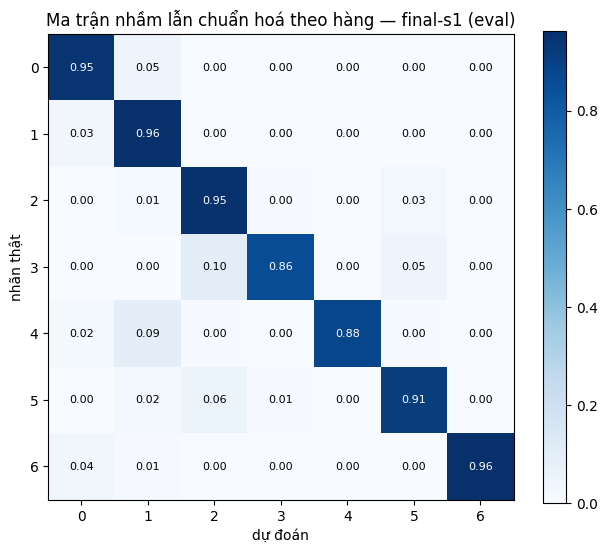

lớp khó nhất: 3 (F1 = 0.8760, support eval = 549, n_train = 1759); hay bị nhầm sang lớp 2 (54 mẫu, 9.8%)


In [20]:
# Phân tích lỗi theo lớp trên eval (mô hình nộp)
with open(f"{OUT_DIR}/eval_result.json", encoding="utf-8") as f:
    ER = json.load(f)
n_train_cls = np.bincount(D["y_tr"].cpu().numpy(), minlength=7)
pc = pd.DataFrame(ER["per_class"]).set_index("cls")
pc["n_train"] = n_train_cls
display(pc.round(4))
cm = np.array(ER["confusion_matrix"])
cm_norm = cm / cm.sum(1, keepdims=True)
display(pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"dự đoán {c}" for c in range(7)]))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_norm, cmap="Blues")
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật"); ax.set_title(f"Ma trận nhầm lẫn chuẩn hoá theo hàng — {SUBMIT_ID} (eval)")
plt.colorbar(im); plt.tight_layout(); plt.show()

worst = int(pc["f1"].idxmin())
off = cm[worst].copy(); off[worst] = 0
print(f"lớp khó nhất: {worst} (F1 = {pc.loc[worst, 'f1']:.4f}, support eval = {pc.loc[worst, 'support']}, n_train = {n_train_cls[worst]}); "
      f"hay bị nhầm sang lớp {int(off.argmax())} ({off.max()} mẫu, {off.max() / cm[worst].sum():.1%})")

**Phân tích lỗi (eval, cấu hình nộp `final-s1`):** accuracy **0,9531**, macro-F1 **0,9294** (baseline `base-s1`: 0,9033 / 0,8410 ⇒ cải thiện +0,0884 macro-F1).

| lớp | loại rừng | support eval | n_train | precision | recall | F1 |
|---|---|---|---|---|---|---|
| 0 | Spruce/Fir | 42 368 | 135 578 | 0,9524 | 0,9472 | 0,9498 |
| 1 | Lodgepole Pine | 56 661 | 181 312 | 0,9573 | 0,9632 | 0,9602 |
| 2 | Ponderosa Pine | 7 151 | 22 882 | 0,9539 | 0,9547 | 0,9543 |
| 3 | Cottonwood/Willow | 549 | 1 759 | 0,8969 | 0,8561 | **0,8760** |
| 4 | Aspen | 1 899 | 6 075 | 0,9086 | 0,8794 | 0,8938 |
| 5 | Douglas-fir | 3 473 | 11 115 | 0,9200 | 0,9110 | 0,9155 |
| 6 | Krummholz | 4 102 | 13 126 | 0,9570 | 0,9559 | 0,9565 |

- **Lớp khó nhất: lớp 3 (Cottonwood/Willow), F1 0,876, recall 0,856.** Trong 549 mẫu, 54 (9,8%) bị đoán thành lớp 2 (Ponderosa Pine) và 25 (4,6%) thành lớp 5
  (Douglas-fir). Lý giải bằng dữ liệu: (1) ít mẫu nhất — chỉ 1 759 mẫu train (0,47%), nên đóng góp rất nhỏ vào loss trung bình; (2) chồng lấn đặc trưng:
  trên train, 100% mẫu lớp 3 thuộc Wilderness_Area_3, độ cao 2 224 ± 102 m; lớp 2 và lớp 5 cũng chủ yếu ở Wilderness_Area_3 (60% và 56%) với độ cao
  2 394 ± 196 m và 2 419 ± 189 m ⇒ các lớp này gần nhau trong không gian đặc trưng, và lớp đông hơn "kéo" ranh giới quyết định về phía mình.
- **Lớp 4 (Aspen)** F1 0,894, recall 0,879: 180/1 899 mẫu (9,5%) bị nhầm thành lớp 1 (Lodgepole Pine), lớp đông nhất có cùng dải độ cao.
- Nhầm lẫn lớn nhất về số tuyệt đối là **lớp 0 ↔ lớp 1** (2 054 + 1 824 mẫu): Spruce/Fir và Lodgepole Pine cùng phân bố ở độ cao trung bình–cao; vì hai lớp
  rất đông nên F1 của chúng vẫn ~0,95–0,96.
- So với baseline, cải thiện lớn nhất ở các lớp hiếm: lớp 4 0,718 → 0,894, lớp 5 0,787 → 0,916, lớp 3 0,777 → 0,876 ⇒ mô hình rộng hơn + huấn luyện lâu hơn
  học được ranh giới mịn hơn giữa các lớp chồng lấn, nên macro-F1 tăng mạnh hơn accuracy (+0,088 vs +0,050).

In [21]:
# Bảng experiments.xlsx (từ results/*.json) + sheet Seeds + nhận xét Summary
all_res = load_results(f"{OUT_DIR}/results")
OPT_NOTE = {"sgd": "SGD momentum=0", "sgd_momentum": "SGD momentum=0.9 (dampening=0, nesterov=False)",
            "adam": "Adam betas=(0.9,0.999) eps=1e-8", "adamw": "AdamW betas=(0.9,0.999) eps=1e-8, wd tách riêng"}
EXTRA = {
    "base-s1": f"trùng cấu hình với lần thử lr={BASE_LR} khi chọn lr (gộp thành 1 dòng)",
    "hp-batch2048-lrx4": "đổi 2 yếu tố: batch 2048 và lr×4 (quy tắc tăng lr theo lô)",
    "clip-none-highlr": "chỉ đổi lr (×10) để tạo tình huống gradient lớn",
    f"clip-{CLIP_C}-highlr": f"đổi 2 yếu tố: lr×10 và clip c={CLIP_C}; so với clip-none-highlr chỉ khác clip",
    f"clip-{CLIP_C}": "c = trung vị grad_norm (TB/epoch) của baseline",
    "amp-bf16": "GPU T4 không có phần cứng BF16 (PyTorch giả lập) -> không tăng tốc",
    "final-s1": "kết hợp 4 yếu tố (optimizer+lr, M-wide, 40 epoch, cosine), chọn bằng val; MÔ HÌNH NỘP",
    "final-s2": "như final-s1, seed 2",
}
def auto_note(r):
    c, s = r["cfg"], r["summary"]
    n = [f"{OPT_NOTE[c['optimizer']]}, wd={c['weight_decay']}",
         f"{math.ceil(len(D['X_tr']) / c['batch']) * c['epochs']} bước cập nhật"]
    if c["loss"] == "mse":
        n.append("MSE = F.mse_loss(logits, one_hot), trung bình trên B×7 phần tử, không hệ số 1/2")
    if s["diverged"]:
        n.append("loss NaN/inf -> dừng sớm (diverged)")
    if EXTRA.get(c["exp_id"]):
        n.append(EXTRA[c["exp_id"]])
    return "; ".join(n)
rows = [to_row(r, EVAL.get(r["cfg"]["exp_id"]), auto_note(r)) for r in all_res]

def group_note(g):
    ids = [r["cfg"]["exp_id"] for r in all_res if r["cfg"]["group"] == g]
    if not ids:
        return None
    best = max(ids, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
    d = RESULTS[best]["summary"]["val_macro_f1"] - BASE_MEAN
    return (f"Tốt nhất: {best} (val F1 {RESULTS[best]['summary']['val_macro_f1']:.4f}, Δ vs TB baseline {d:+.4f}, "
            f"2σ = {TWO_SIGMA:.4f} -> {'vượt nhiễu' if abs(d) > TWO_SIGMA else 'trong nhiễu'})")

notes = {g: group_note(g) for g in ["baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "final"]}
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=base_ids, summary_notes={k: v for k, v in notes.items() if v})
print("đã ghi experiments.xlsx với", len(rows), "dòng")

# kiểm tra: mỗi dòng có đúng một ảnh figures/<exp_id>.png
ids = {r["exp_id"] for r in rows}
pngs = {os.path.splitext(f)[0] for f in os.listdir(f"{OUT_DIR}/figures") if not f.startswith("compare_")}
print("thiếu ảnh:", ids - pngs or "không", "| ảnh thừa:", pngs - ids or "không")
display(pd.DataFrame(rows).set_index("exp_id")[["group", "optimizer", "lr", "val_acc", "val_macro_f1", "eval_acc", "eval_macro_f1"]])

đã ghi experiments.xlsx với 31 dòng
thiếu ảnh: không | ảnh thừa: không


,group,optimizer,lr,val_acc,val_macro_f1,eval_acc,eval_macro_f1
exp_id,,,,,,,
amp-bf16,amp,SGD+momentum,0.1000,0.9062,0.8469,NaN,NaN
amp-fp16,amp,SGD+momentum,0.1000,0.9058,0.8484,NaN,NaN
base-s1,baseline,SGD+momentum,0.1000,0.9054,0.8390,0.9033,0.8410
base-s2,baseline,SGD+momentum,0.1000,0.9100,0.8601,NaN,NaN
base-s3,baseline,SGD+momentum,0.1000,0.9091,0.8614,NaN,NaN
clip-0.57,clipping,SGD+momentum,0.1000,0.9043,0.8537,NaN,NaN
clip-0.57-highlr,clipping,SGD+momentum,1.0000,0.8783,0.8046,NaN,NaN
clip-none-highlr,clipping,SGD+momentum,1.0000,0.8662,0.7732,NaN,NaN
drop-0.1,dropout,SGD+momentum,0.1000,0.9005,0.8402,NaN,NaN
